# Veri Setinin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd

panel = pd.read_csv(
    "panel.csv",
    parse_dates=["month"],   # month datetime olarak gelsin
    dtype={
        "loan_id": "int32",
        "customer_id": "int32",
        "credit_history_months": "int16",
        "product_count": "int16",
        "salary_customer": "int8",
        "term_months": "int8",
        "past_due_30d_count": "int16",
        "default_12m": "int8"
    }
)

# Exploratory Data Analysis (EDA)

Bu bölümde veri setinin temel yapısı, değişken dağılımları, veri tipleri, eksik değer durumu ve hedef değişkenin genel görünümü incelenmiştir. Amaç, model kurulumundan önce veri kalitesini ve değişkenlerin temel davranışlarını anlamaktır.

In [2]:
panel.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
loan_id,432000.0,9000.5,1.0,4500.75,9000.5,13500.25,18000.0,5196.158429
customer_id,432000.0,5966.214389,1.0,2994.75,5961.0,8950.25,12000.0,3454.998383
income,432000.0,39071.765942,6085.057086,25998.974133,35146.989916,47749.148416,226649.934899,18560.364285
credit_history_months,432000.0,92.152833,6.0,49.0,92.0,135.0,179.0,50.176154
product_count,432000.0,2.332278,1.0,1.0,2.0,3.0,10.0,1.354657
salary_customer,432000.0,0.450444,0.0,0.0,0.0,1.0,1.0,0.497539
loan_amount,432000.0,216042.424749,18272.095381,119957.378132,179474.081368,269505.589602,1757913.819445,143721.477629
term_months,432000.0,28.756667,12.0,24.0,24.0,36.0,48.0,11.658063
interest_rate,432000.0,24.325416,13.390204,21.989171,23.918631,26.073696,55.0,3.506501
dti,432000.0,0.264504,0.02,0.120275,0.253056,0.385275,0.95,0.177333


In [3]:
panel.head(50)

,loan_id,customer_id,income,credit_history_months,product_count,salary_customer,loan_amount,term_months,interest_rate,dti,utilization,month,cpi_yoy,policy_rate,unemployment,digital_activity_score,last_3m_spend,past_due_30d_count,default_12m,lgd
0,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-01-01,45.243774,34.785836,9.135783,57.964145,26115.500173,0,0,0.224459
1,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-02-01,44.411786,34.609769,9.149299,33.194927,24353.286858,1,1,0.200567
2,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-03-01,45.012147,34.875924,9.207122,59.921787,18921.648782,1,0,0.332859
3,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-04-01,45.764599,35.058646,9.333380,56.180318,22000.990353,0,0,0.264601
4,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-05-01,44.203771,35.265012,9.041949,60.911284,19233.539632,0,0,0.155456
5,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-06-01,43.162027,35.480423,8.978015,51.859140,15943.605659,1,0,0.404218
6,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-07-01,43.264300,36.551247,8.883940,62.741754,24208.889328,1,0,0.281958
7,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-08-01,43.011306,36.348039,8.756165,46.835994,19452.458282,1,0,0.206955
8,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-09-01,42.997865,36.091918,8.701136,71.988808,20503.775523,0,0,0.146789
9,1,9861,87942.308585,33,1,1,258749.553241,24,23.809806,0.227112,0.062761,2024-10-01,42.315430,35.685031,9.000124,63.125278,19872.416355,1,0,0.206044


İlk gözlemler incelendiğinde veri setinin kredi-ay düzeyinde panel yapıda olduğu görülmektedir. Aynı kredi farklı aylarda tekrar gözlemleniyor, bu sayede zaman boyutunda risk analizi yapılabiliriz.

**Veri Kalitesi ve Yapısal Kontroller**

In [4]:
print("panel.shape =", panel.shape)

panel.shape = (432000, 20)


In [5]:
display(panel.dtypes)

loan_id                            int32
customer_id                        int32
income                           float64
credit_history_months              int16
product_count                      int16
salary_customer                     int8
loan_amount                      float64
term_months                         int8
interest_rate                    float64
dti                              float64
utilization                      float64
month                     datetime64[ns]
cpi_yoy                          float64
policy_rate                      float64
unemployment                     float64
digital_activity_score           float64
last_3m_spend                    float64
past_due_30d_count                 int16
default_12m                         int8
lgd                              float64
dtype: object

In [6]:
display(panel.isna().mean().sort_values(ascending=False).head(10)) #N/A değerler var mı baktık.

loan_id                   0.0
customer_id               0.0
default_12m               0.0
past_due_30d_count        0.0
last_3m_spend             0.0
digital_activity_score    0.0
unemployment              0.0
policy_rate               0.0
cpi_yoy                   0.0
month                     0.0
dtype: float64

In [7]:
(panel == 0).mean().sort_values(ascending=False) #Sayısal değişkenlerde sıfır değer yoğunluğunu inceliyoruz. Bu kontrol özellikle bazı alanlarda ekonomik ve mantıksal olarak anlamlı olmayan sıfır değerlerin bulunup bulunmadığını görmek için yaparız.

default_12m               0.740715
salary_customer           0.549556
past_due_30d_count        0.435368
last_3m_spend             0.000069
loan_id                   0.000000
month                     0.000000
digital_activity_score    0.000000
unemployment              0.000000
policy_rate               0.000000
cpi_yoy                   0.000000
utilization               0.000000
customer_id               0.000000
dti                       0.000000
interest_rate             0.000000
term_months               0.000000
loan_amount               0.000000
product_count             0.000000
credit_history_months     0.000000
income                    0.000000
lgd                       0.000000
dtype: float64

In [8]:
print("default_12m rate= =", panel["default_12m"].mean())  # Default olanların oranını çıkardık.

default_12m rate= = 0.2592847222222222


**Korelasyon Analizi**

In [9]:
corr = panel.corr(numeric_only=True)["default_12m"].sort_values(ascending=False) # Bağımlı değişkenimizin bağımsız değişkenlerle olan korelasyonunu inceliyoruz
print(corr.head(19))

default_12m               1.000000
dti                       0.344291
utilization               0.340763
lgd                       0.290000
past_due_30d_count        0.261584
last_3m_spend             0.016098
policy_rate               0.003129
loan_id                   0.002141
unemployment              0.001518
cpi_yoy                   0.000343
term_months              -0.000761
customer_id              -0.002169
credit_history_months    -0.003159
interest_rate            -0.004400
loan_amount              -0.006330
digital_activity_score   -0.023546
salary_customer          -0.032823
product_count            -0.039615
income                   -0.063124
Name: default_12m, dtype: float64


Korelasyon sonuçlarına göre dti, utilization ve past_due_30d_count değişkenleri hedef değişken ile en güçlü pozitif ilişkiye sahip görünmekte. income, product_count ve salary_customer ise negatif yönlü ilişki göstermekte. Ancak korelasyon analizi yalnızca doğrusal ilişkiyi gösterdiğinden değişkenlerin modele katkısı nihai olarak lojistik regresyon çıktıları ile değerlendirilecek.

Not: Korelasyon testi sonucu LGD değişkeninin bağımlı değişkenimiz ile belirli düzeyde ilişki gösterdiği görülüyor. Ancak LGD temerrüt gerçekleştikten sonra ortaya çıkan bir risk parametresi olduğundan PD modelinde bağımsız değişken olarak kullanılmayacak. PD, LGD ve EAD bankacılık risk modellemesinde ayrı parametreler olarak modellenir.

****

## Cut-off + Train/Test Ayrımı

In [10]:
panel_sorted = panel.sort_values("month") # Veriyi eskiden yeniye sıralarız

In [11]:
cutoff = panel_sorted["month"].max() - pd.offsets.MonthBegin(4)

In [12]:
print(cutoff)

2025-08-01 00:00:00


In [13]:
print(panel_sorted["month"].max(), panel_sorted["month"].min())  # Veriseti tarih aralığı kontrolü

2025-12-01 00:00:00 2024-01-01 00:00:00


In [14]:
# Eğitim veriseti için
train = panel_sorted[panel_sorted["month"] < cutoff].copy() 

In [15]:
# Test veriseti için
test = panel_sorted[panel_sorted["month"] >= cutoff].copy()

In [16]:
print("Train months:", train["month"].min(), "->", train["month"].max(), " | n=", len(train))
print("Test  months:", test["month"].min(),  "->", test["month"].max(),  " | n=", len(test))

Train months: 2024-01-01 00:00:00 -> 2025-07-01 00:00:00  | n= 342000
Test  months: 2025-08-01 00:00:00 -> 2025-12-01 00:00:00  | n= 90000


Veri seti zaman boyutu içerdiği için rastgele train-test ayrımı yerine kronolojik ayrım tercih ettik. Böylece model geçmiş dönem verileri üzerinden eğitilip, sonraki dönem performansı ise out of time validation yaklaşımıyla test edilir.

# Modelde Kullanılacak Değişkenlerin Belirlenmesi

In [17]:
import statsmodels.api as sm

In [18]:
features = [
    "dti",
    "utilization",
    "past_due_30d_count",
    "income",
    "salary_customer",
    "product_count",
    "policy_rate",
    "unemployment",
    "cpi_yoy"
]
# Logit modelinde tüm değişkenler değil, ekonomik olarak güçlü ve yorumlanabilir çekirdek risk driver’ları seçilir. 
# Korelasyonlu değişkenler tamamen dışlanmaz; farklı ekonomik hikaye taşıyorlarsa birlikte tutulabilir. Ancak yüksek korelasyon durumları multicollinearity (ÇDB) şüphesi doğurabilir. Bu nedenle ciddi bir multicollinearity durumu olup olmadığını VIF kriterine bakarak test edeceğiz.

**Çoklu Doğrusal Bağlantı**

Modelde kullanacağımız bağımsız değişkenleri belirledikten sonra, bu değişkenler arasında çoklu doğrusal bağlantı olup olmadığını kontrol etmek için varyans şişirme faktörü (VIF) uygularız. Analiz yalnızca eğitim veri seti üzerinde gerçekleştirilerek veri sızıntısı (data leakage) önlenir.

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

X = train[features]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,variable,VIF
0,const,17775.483514
1,dti,3.142236
2,utilization,3.149121
3,past_due_30d_count,1.148748
4,income,1.000343
5,salary_customer,1.000142
6,product_count,1.000315
7,policy_rate,1.703573
8,unemployment,1.528162
9,cpi_yoy,1.330083


Analiz sonuçlarına göre tüm değişkenlerin VIF değerleri kabul edilebilir seviyelerde (VIF < 5) bulunmuş olup modelde önemli bir multicollinearity (ÇDB) problemi tespit edilmemiştir. DTI ve utilization değişkenlerinin VIF değerleri diğer değişkenlere göre daha yüksek olsa da bu durum ekonomik olarak beklenmektedir ve modelin istatistiksel stabilitesini bozacak bir durum değildir.

# Lojistik Regresyon Modeli

In [20]:
x_train = train[features]
y_train = train["default_12m"]

In [21]:
x_train_const = sm.add_constant(x_train) # alternatif tek seferde: x_train = sm.add_constant(train[features])

In [22]:
logit_model = sm.Logit(y_train, x_train_const) # Logit modeli tanımladık

In [23]:
# sm.Logit her müşteri için: 0 ile 1 arasında default olasılığı üretir.

In [24]:
logit_res = logit_model.fit(disp=False) #fit edildi train edildi

In [25]:
logit_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            default_12m   No. Observations:               342000
Model:                          Logit   Df Residuals:                   341990
Method:                           MLE   Df Model:                            9
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1402
Time:                        04:58:09   Log-Likelihood:            -1.6811e+05
converged:                       True   LL-Null:                   -1.9552e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.6492      0.568     -6.422      0.000      -4.763      -2.535
dti                    2.3640      0.041     57.290      0.000       2.283       2.445
utilization            1.7410      0.033     52.863      0.000       1.676       1.806
past_due_30d_count     0.3363      0.004     83.289      0.000       0.328       0.344
income             -1.005e-05   2.45e-07    -41.065      0.000   -1.05e-05   -9.57e-06
salary_customer       -0.1909      0.009    -22.149      0.000      -0.208      -0.174
product_count         -0.0815      0.003    -25.322      0.000      -0.088      -0.075
policy_rate            0.0238      0.009      2.718      0.007       0.007       0.041
unemployment           0.0678      0.027      2.536      0.011       0.015       0.120
cpi_yoy                0.0011      0.006      0.191      0.849      -0.010       0.012
======================================================================================
"""

İlk model sonuçlarına göre dti, utilization ve past_due_30d_count değişkenleri temerrüt olasılığını artıran anlamlı risk faktörleri olarak öne çıkıyor. income, salary_customer ve product_count değişkenleri ise beklenen şekilde koruyucu yönde çalışmaktadır (ilgili değişken arttıkça temerrüt olasılığı azalır). cpi_yoy değişkeni bu spesifikasyonda istatistiksel olarak anlamlı değildir.

**Robust Standart Hatalar**

In [26]:
# Heteroskedasiteye karşı daha güvenilir standart hata, p-value ve güven aralığı elde edelim.

In [27]:
logit_res_robust = logit_model.fit(disp="False", cov_type="HC1") #train edilen model robust tanımlandı
logit_res_robust.summary()

Optimization terminated successfully.
         Current function value: 0.491545
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            default_12m   No. Observations:               342000
Model:                          Logit   Df Residuals:                   341990
Method:                           MLE   Df Model:                            9
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1402
Time:                        04:58:10   Log-Likelihood:            -1.6811e+05
converged:                       True   LL-Null:                   -1.9552e+05
Covariance Type:                  HC1   LLR p-value:                     0.000
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.6492      0.568     -6.421      0.000      -4.763      -2.535
dti                    2.3640      0.041     57.392      0.000       2.283       2.445
utilization            1.7410      0.033     52.953      0.000       1.677       1.805
past_due_30d_count     0.3363      0.004     83.028      0.000       0.328       0.344
income             -1.005e-05   2.44e-07    -41.169      0.000   -1.05e-05   -9.57e-06
salary_customer       -0.1909      0.009    -22.147      0.000      -0.208      -0.174
product_count         -0.0815      0.003    -25.325      0.000      -0.088      -0.075
policy_rate            0.0238      0.009      2.718      0.007       0.007       0.041
unemployment           0.0678      0.027      2.535      0.011       0.015       0.120
cpi_yoy                0.0011      0.006      0.191      0.849      -0.010       0.012
======================================================================================
"""

**Odds Ratio ve Katsayıların Ekonomik Yorumu**

Lojistik regresyon katsayıları log-odds cinsinden yorumlandığı için doğrudan sezgisel değildir. Bu nedenle katsayılar üstel dönüşümden geçirilerek odds ratio değerleri hesaplanmış ve değişkenlerin temerrüt odds’u üzerindeki etkisi daha yorumlanabilir hale getirilir:

In [28]:
params = logit_res_robust.params
conf = logit_res_robust.conf_int()
or_table = pd.DataFrame({
    "coef": params,
    "odds_ratio": np.exp(params),
    "ci_low_or": np.exp(conf[0]),
    "ci_high_or": np.exp(conf[1]),
    "pvalue":  logit_res_robust.pvalues
}).sort_values("pvalue")

In [29]:
or_table

,coef,odds_ratio,ci_low_or,ci_high_or,pvalue
dti,2.364050,10.633931,9.809166,11.528044,0.000000e+00
utilization,1.740972,5.702884,5.346984,6.082474,0.000000e+00
past_due_30d_count,0.336326,1.399795,1.388725,1.410952,0.000000e+00
income,-0.000010,0.999990,0.999989,0.999990,0.000000e+00
product_count,-0.081517,0.921717,0.915920,0.927550,1.712032e-141
salary_customer,-0.190875,0.826236,0.812396,0.840311,1.127091e-108
const,-3.649169,0.026013,0.008539,0.079240,1.354582e-10
policy_rate,0.023774,1.024059,1.006654,1.041765,6.562929e-03
unemployment,0.067790,1.070140,1.015507,1.127714,1.122888e-02
cpi_yoy,0.001052,1.001053,0.990293,1.011930,8.486295e-01


Dti 1 birim artarsa şeklinde yorum yapmak mantıklı değildir zira dti 0-1 arasında değer alır bu sebeple 
Temerrüt olma ihtimalinin, temerrüt olmama ihtimaline oranı olan default odds değerini şöyle hesaplamak daha uygundur;

e^2.364×0.1 ≈ 1.27 ---->  (Yüzde degişim = (OR−1)×100) 

Yorum: DTI’daki 10 puanlık artış, temerrüt gerçekleşme odds’unu yaklaşık %27 artırıyor; bu da başlangıç risk seviyesine bağlı olarak temerrüt olasılığını anlamlı ölçüde yükseltiyor.

Örneğin başlangıç Riski (PD)
%5 iken:
Başlangıç Odds = 0.05 / 0.95 = 0.0526 --- Dti den kaynaklanan Yeni Odds: 0.0526 × 1.27 = 0.0668
Ve yeni PD için = 0.0668 / (1+0.0668) ≈ 0.0626
%5 ----> %6.26 yani artış 1.26 puan

%20 iken:
Odds = 0.20 / 0.80 = 0.25
Yeni Odds = 0.25 × 1.27 = 0.3175
Yeni PD ≈ 0.241 
%20 ----> %24.1 
Artış 4.1 puan

__________________________________

# Modelin Ayırma Gücü: AUC, ROC Eğrisi ve KS Metriği

_____________________________________

**AUC**

AUC = Area Under the ROC Curve (ROC eğrisinin altında kalan alan)

AUC, modelin “iyi müşteri” ile “kötü müşteriyi” ayırma gücünü ölçer.

yani:

Model, rastgele seçilen bir temerrüt müşterisine rastgele seçilen sağlam müşteriden daha yüksek risk skoru verir mi? P(Default müştersinin skoru > Non-default müşterisinin skoru)

In [30]:
from sklearn.metrics import roc_auc_score

x_test = test[features]
x_test_const = sm.add_constant(x_test, has_constant="add")
test_pred = logit_res_robust.predict(x_test_const)          # eğitilmiş logit modelinin test setindeki her gözlem için ürettiği tahmini temerrüt olasılıklarını (PD skorlarını) içerir.

# Alternatif
# X_test = sm.add_constant(test[features], has_constant="add")
# test_pred = logit_res_robust.predict(X_test) 

auc = roc_auc_score(test["default_12m"], test_pred) #test["default_12m"] gerçek sonuçlar
print("Test Auc:", auc)

Test Auc: 0.7460502480826692


Model, rastgele seçilen bir temerrüt müşterisine rastgele seçilen temerrütsüz müşteriden daha yüksek risk skoru verme olasılığı açısından yaklaşık %74.6’lık bir ayrıştırma gücüne sahip.

**ROC eğrisini çizelim**

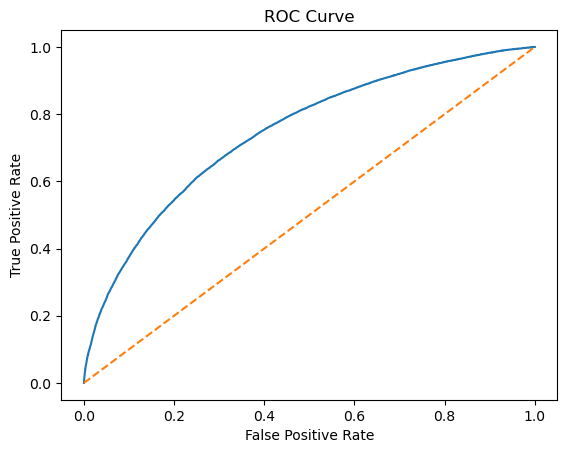

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(test["default_12m"], test_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**Kolmogorov–Smirnov (KS)**

Kolmogorov–Smirnov (KS) istatistiği, modelin temerrüt eden ve etmeyen müşterileri ne kadar iyi ayırt edebildiğini ölçen bir performans metriğidir. KS değeri, temerrüt eden ve etmeyen müşteri gruplarının kümülatif dağılımları arasındaki maksimum farkı ifade eder.

| KS        | Yorum |
| --------- | ----- |
| < 0.2     | Zayıf |
| 0.2 – 0.3 | Orta  |
| 0.3 – 0.4 | İyi   |

In [32]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(test["default_12m"], test_pred)

ks = np.max(tpr - fpr)

print("KS:", ks)

KS: 0.3641575571237704


Model için hesaplanmış KS değeri yaklaşık **0.36** olarak bulundu. Risk modellemesinde KS değerinin 0.30 üzerinde olması modelin temerrüt eden ve etmeyen müşterileri ayırt etme konusunda iyi bir performans gösterdiğini söylüyor.

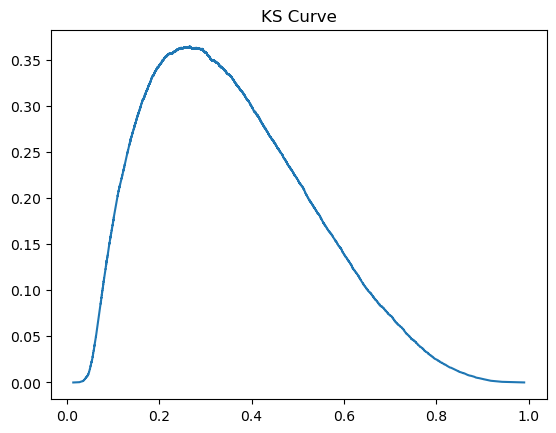

In [33]:
plt.plot(thresholds, tpr - fpr)
plt.title("KS Curve")
plt.show()

KS grafiğinde görülen maksimum fark noktası, modelin temerrüt eden ve etmeyen müşteri dağılımlarını en iyi ayırdığı eşiği temsil eder.

# Risk Sıralama Performansı

***Decile Analizi***

En riskli diye işaretlediğim grup gerçekten daha mı çok temerrüt ediyor?

Decile analizi şunu gösterir:

PD’yi 10 gruba (decile) böl

Her grupta:

  - ortalama PD (model ne diyor?)

  - gerçekleşen default oranı (gerçek ne olmuş?)

  - kaç kayıt var (istatistiki güven)

In [34]:
## 1) test_pred'i test tablosuna ekliyoruz (yeni bir kolon)
test = test.copy()   # orijinali bozmamak için kopya# 
test["pd_pred"] = test_pred     # modelin PD tahminleri

In [35]:
# 2) pd_pred’i 10 eşit parçaya bölüyoruz (qcut = quantile cut)
# labels=False -> 0,1,2,...,9 olarak etiketler
test["decile"] = pd.qcut(test["pd_pred"], 10, labels=False)

In [36]:
# 3) her decile için özet tablo üretiyoruz
decile_table = (
    test.groupby("decile")
        .agg(
            count=("default_12m", "size"),  # kaç satır var?
            avg_pd=("pd_pred", "mean"),      # modelin ortalama PD’si
            default_rate=("default_12m","mean")  # gerçekleşen default oranı (Bernoulli değişkeninde mean oran'a eşit)
        )
        .sort_index()
)

decile_table

,count,avg_pd,default_rate
decile,,,
0,9000,0.062802,0.064000
1,9000,0.091373,0.094000
2,9000,0.120695,0.125667
3,9000,0.153992,0.153222
4,9000,0.191860,0.190556
5,9000,0.236676,0.239556
6,9000,0.290960,0.292667
7,9000,0.359559,0.356222
8,9000,0.457662,0.455778


Model riskli müşterileri olması gerektiği gibi yukarı doğru sıralamış. Decile yapısı düzgün.
Üstelik kalibrasyon yapmamamıza rağmen model ile gerçekleşen değerler neredeyse birebir bunun sebebi sentetik verimizi Logit üretirken modelimizi de Logit olarak kurduk.
Yani:
       Gerçek dünya  ---> logit
      , Tahmin modeli ---> logit

Gerçek hayatta:

   - Veri gürültülüdür

   - Davranış dinamik değişir

   - Ölçüm hatası vardır

   - Değişkenler eksiktir

   - Non-linear yapı vardır

In [37]:
#Buna rağmen modelin tahmin ettiği PD seviyelerinin gerçekleşen oranlarla ne ölçüde uyumlu olduğunu görmek amacıyla ayrıca kalibrasyon analizi uygulayacağız.

***Kalibrasyon (Diagnostic)***

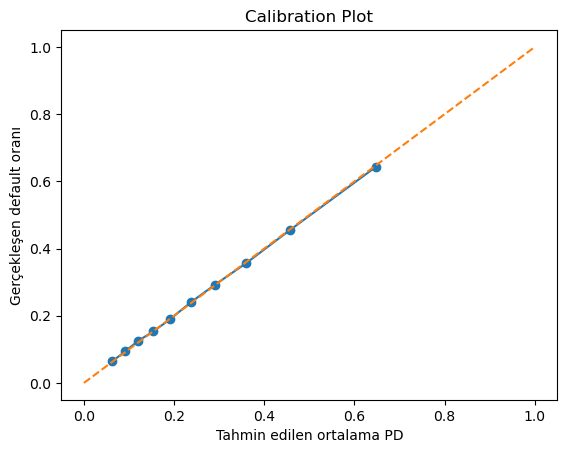

,avg_pd,default_rate,count
pd_bin,,,
"(0.013000000000000001, 0.078]",0.062802,0.064000,9000
"(0.078, 0.105]",0.091373,0.094000,9000
"(0.105, 0.136]",0.120695,0.125667,9000
"(0.136, 0.172]",0.153992,0.153222,9000
"(0.172, 0.213]",0.191860,0.190556,9000
"(0.213, 0.262]",0.236676,0.239556,9000
"(0.262, 0.322]",0.290960,0.292667,9000
"(0.322, 0.401]",0.359559,0.356222,9000
"(0.401, 0.524]",0.457662,0.455778,9000


In [38]:
import matplotlib.pyplot as plt

# 1) 10 bin (bin = aralık) yapıyoruz
test["pd_bin"] = pd.qcut(test["pd_pred"], 10, duplicates="drop")

cal_table = (
    test.groupby("pd_bin", observed = True)
        .agg(
            avg_pd=("pd_pred", "mean"),
            default_rate=("default_12m", "mean"),
            count=("default_12m", "size")
        )
)

# 2) Grafik: x=avg_pd, y=default_rate
plt.plot(cal_table["avg_pd"], cal_table["default_rate"], marker="o")
plt.plot([0, 1], [0, 1], "--")  # mükemmel kalibrasyon çizgisi
plt.xlabel("Tahmin edilen ortalama PD")
plt.ylabel("Gerçekleşen default oranı")
plt.title("Calibration Plot")
plt.show()

cal_table

# Stabilite ve Backtesting Analizi

***Aylık AUC***

In [39]:
t = test.copy()
t["pd_pred"] = test_pred

monthly_auc = (
    t.groupby("month")[["default_12m","pd_pred"]]
     .apply(lambda df: roc_auc_score(df["default_12m"], df["pd_pred"]))
     .reset_index(name="auc")   #Bu index'i normal sütun yapar 
     .sort_values("month")
)

monthly_auc     # Dalgalanmalara bakarız: max(AUC)-min(AUC) => <0.03 → iyi  0.03–0.05 → izlenmeli 0.05 → alarm

,month,auc
0,2025-08-01,0.741543
1,2025-09-01,0.744792
2,2025-10-01,0.743730
3,2025-11-01,0.746374
4,2025-12-01,0.753798


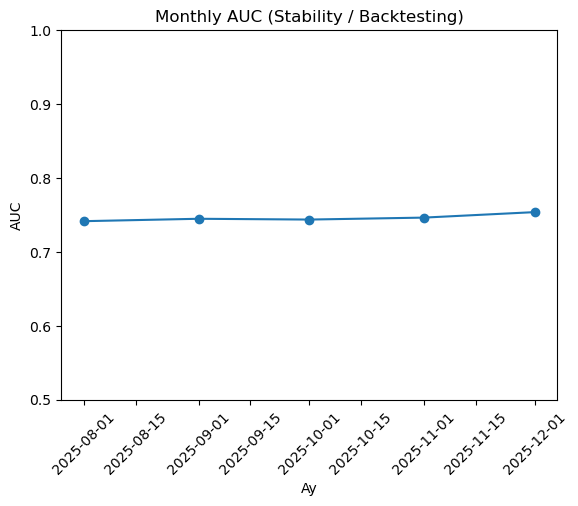

In [40]:
plt.plot(monthly_auc["month"], monthly_auc["auc"], marker="o")
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0) # Model stabilite grafiklerinde y-ekseni dar tutulursa küçük değişimler abartılı görünür, yönetim sunumlarında standardize edilmiş eksen kullanmak görsel yanlılığı azaltır.
plt.xlabel("Ay")
plt.ylabel("AUC")
plt.title("Monthly AUC (Stability / Backtesting)")
plt.show()

**Aylık Kalibrasyon Analizi**

In [41]:
# Modelin söylediği risk oranı avg_pd gerçek default oranına yakın mı ?

monthly_cal = (
    t.groupby("month")
     .agg(
         avg_pd=("pd_pred", "mean"),
         default_rate=("default_12m", "mean"),
         n=("default_12m", "size")
     )
    .reset_index()
    .sort_values("month")
)

monthly_cal

,month,avg_pd,default_rate,n
0,2025-08-01,0.259948,0.262167,18000
1,2025-09-01,0.262607,0.260556,18000
2,2025-10-01,0.262468,0.261889,18000
3,2025-11-01,0.261982,0.263167,18000
4,2025-12-01,0.259837,0.259889,18000


# Eşik Seçimi (Cut-off) Analizi ve Confusion Matrix

Şimdiye kadar:

   - Model sıralıyor mu?  (AUC/decile)

   - PD’ler gerçekçi mi?  (kalibrasyon)

Artık iş sorusu şu:

   - Hangi PD üstünü riskli sayalım?

   

**Confusion matrix nasıl okunur?**

- TN: Gerçekte temerrüt etmeyen ve model tarafından doğru şekilde risksiz sınıflanan müşteri

- FP: Gerçekte temerrüt etmeyen ancak model tarafından riskli sınıflanan müşteri

- FN: Gerçekte temerrüt eden ancak model tarafından kaçırılan müşteri (bankada pahalı)

- TP: Gerçekte temerrüt eden ve model tarafından doğru şekilde riskli sınıflanan müşteri

Bankacılıkta genelde FN maliyeti daha ağırdır.

[[TN FP]

 [FN TP]]

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_threshold(th):
    pred_class = (test["pd_pred"] >= th).astype(int)

    cm = confusion_matrix(test["default_12m"], pred_class)

    print("Threshold:", th)
    print("Confusion Matrix:\n", cm)
    print(classification_report(test["default_12m"], pred_class, digits=3))
    print("-"*40)

for th in [0.05, 0.10, 0.15, 0.20]:
    evaluate_threshold(th)

Threshold: 0.05
Confusion Matrix:
 [[ 1122 65340]
 [   55 23483]]
              precision    recall  f1-score   support

           0      0.953     0.017     0.033     66462
           1      0.264     0.998     0.418     23538

    accuracy                          0.273     90000
   macro avg      0.609     0.507     0.226     90000
weighted avg      0.773     0.273     0.134     90000

----------------------------------------
Threshold: 0.1
Confusion Matrix:
 [[15012 51450]
 [ 1243 22295]]
              precision    recall  f1-score   support

           0      0.924     0.226     0.363     66462
           1      0.302     0.947     0.458     23538

    accuracy                          0.415     90000
   macro avg      0.613     0.587     0.411     90000
weighted avg      0.761     0.415     0.388     90000

----------------------------------------
Threshold: 0.15
Confusion Matrix:
 [[27483 38979]
 [ 3070 20468]]
              precision    recall  f1-score   support

           0

Model eşik arttıkça yanlış alarm oranını azaltmakta, ancak riskli müşteri yakalama oranı düşmektedir. 0.15–0.20 aralığı precision–recall dengesi açısından optimum operasyonel bölge olarak görünmektedir.
Risk ekipleri yanlış alarmı tolere eder,
ama kaçırılmış default’u tolere etmez.

- Class 0 için precision : Modelin risksiz dediği müşterilerin kaç tanesi gerçekten risksiz?
- Class 0 için recall : Gerçekte risksiz olan müşterilerin kaçını model doğru şekilde risksiz olarak yakaladı?
- Class 1 için precision : Modelin riskli dediği müşterilerin kaç tanesi gerçekten riskli?
- Class 1 için recall : Gerçekte temerrüt eden müşterilerin kaçını model yakalayabildi?

Threshold = 0.2 iken model, temerrüt eden müşterilerin yaklaşık %78’ini yakalayabilmekte (recall ≈ 0.78), ancak riskli olarak işaretlenen müşterilerin %38’i gerçekten risklidir (precision ≈ 0.39). Bu sonuçlar modelin erken uyarı amacıyla kullanılabilecek seviyede bir yakalama kapasitesine sahip olduğunu göstermektedir.


# Watchlist Yaklaşımı

***Bankacılıkta threshold yerine Top X% tercih edilir peki neden ?***

- Operasyon kapasitesi sabittir.
- Risk ekibi ayda belirli sayıda müşteri inceleyebilir
- Precision ve Recall tek başına karar verdirmez

  Bu sebeple:
- Model kim daha riskli diye sıralar
- İş birimi kaç kişiyle aksiyon alabilirz der
  ve Top X% seçilir.

 

***Watchlist Seçimi***

Test veri setimizde 90000 müşteri

Varsayalım ki risk ekibi kapsitemiz de ayda 9000 müşteri

Yani:

  - En riskli %10 watchlist'e girer

In [43]:
watch = test.copy()
watch["pd_pred"] = test_pred

watch = watch.sort_values("pd_pred", ascending = False) #en riskli üstte olacak şekilde sıraladık ve sıralamayı kaydettik

In [44]:
# Risk rank'ı oluştururuz. Kişi risk sıralamasında kaçıncı yüzdelikte?

watch["risk_rank_pct"] = (
    watch["pd_pred"].rank(method="first", pct=True)
)

# 0 --> en düşük risk, 1--> en yüksek risk    

In [45]:
# En riskli %10 seçelim 

watchlist = watch[watch["risk_rank_pct"] >= 0.90]

# Watchlist Performansı: Capture Rate ve Lift

In [46]:
# Capture Rate (çok kritik)
# Default olan müşterilerin kaçını watchlist yakalıyor?

total_defaults = watch["default_12m"].sum()
captured_default = watchlist["default_12m"].sum()
capture_rate = captured_default / total_defaults

print("Capture Rate:", capture_rate)

Capture Rate: 0.2461551533690203


In [47]:
# Lift Metric

watch_dr = watch["default_12m"].mean()
watchlist_dr = watchlist["default_12m"].mean()
lift = watchlist_dr / watch_dr

print("Lift:", lift)


Lift: 2.4612780583503864


| Capture (@Top10%) | Yorum         |
| ----------------- | ------------- |
| ~10%              | random (kötü) |
| 15–20%            | kabul         |
| 20–30%            | iyi           |
| 30%+              | güçlü         |


Model tarafından oluşturulan watchlist, toplam temerrütlerin %24.6’sını yakalarken, genel portföye kıyasla 2.46 kat daha yüksek risk yoğunluğu göstermektedir.

# Capture Curve ve Lift Curve

In [48]:
# Capture Curve (Risk ekibi kaç müşteri işlerse kaç default yakalar)

In [49]:
watch_curve = watch.copy()

watch_curve = watch_curve.sort_values("pd_pred", ascending = False).reset_index(drop=True)  # yüksek risk üstte

total_defaults = watch_curve["default_12m"].sum()                                           

watch_curve["cum_defaults"] = watch_curve["default_12m"].cumsum()                           # sıralı kümülatif default
watch_curve["cum_population_pct"] = (np.arange(1, len(watch_curve)+1))/len(watch_curve)     # yüzde olarak müşteri oranı
watch_curve["capture_rate"] = watch_curve["cum_defaults"] / total_defaults                  # capture rate

In [50]:
base_dr = watch_curve["default_12m"].mean()

watch_curve["cum_default_rate"] = watch_curve["cum_defaults"] / (np.arange(1, len(watch_curve)+1))    # kümülatif sıralı default oranı (np.arange(1, len(watch_curve)+1))  => şuana kadar kaç kişiye baktık.  şu ana kadar default sayısı / şuana kadar bakılan kişi = cum default rate
watch_curve["lift"] = watch_curve["cum_default_rate"] / base_dr                                       # kümülatif lift

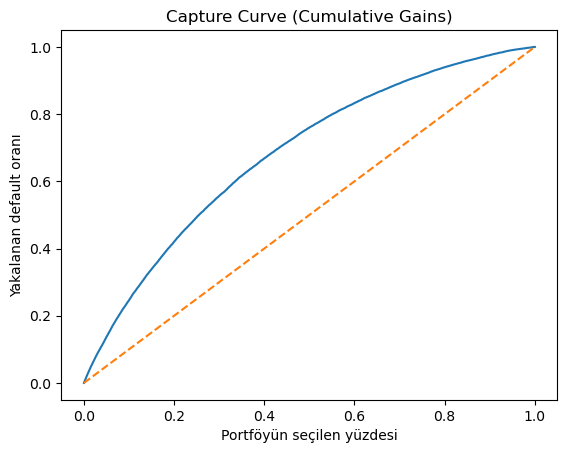

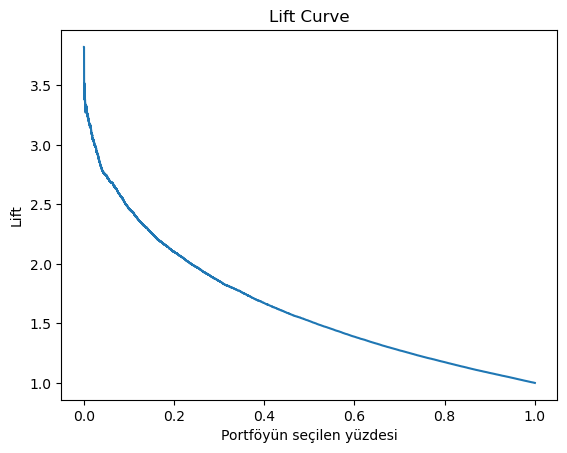

In [51]:
# Grafikte görelim

#Capture Curve

plt.plot(watch_curve["cum_population_pct"], watch_curve["capture_rate"])
plt.plot([0,1],[0,1],"--")
plt.xlabel("Portföyün seçilen yüzdesi")
plt.ylabel("Yakalanan default oranı")
plt.title("Capture Curve (Cumulative Gains)")
plt.show()

# lift Curve

plt.plot(watch_curve["cum_population_pct"], watch_curve["lift"])
plt.xlabel("Portföyün seçilen yüzdesi")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.show()

Capture Curve: Eğri ne kadar yukarıdaysa model o kadar iyi. Düz çizgi random seçim.

Lift Curve: Başlangıçta yüksek olur. Sonra düşer. 1'e yaklaşır (rastgelelik)

Capture curve’in şekli şunu gösteriyor:

İlk %10 çok değerli, %20 sonrası marjinal kazanç azalıyor.

Azalan Marjinal Getiri

Yani:
Liste büyüdükçe yakalanan ek temerrüt sayısı artmakla birlikte, her ilave müşteri grubunun sağladığı marjinal katkı giderek azalmaktadır.

***Gerçek bankacılık segmentasyonu*** 
- Tek watchlist yok


| Segment | PD     | Aksiyon             |
| ------- | ------ | ------------------- |
| Green   | düşük  | normal izleme       |
| Amber   | orta   | SMS / hafif aksiyon |
| Red     | yüksek | arama / collection  |

# Early Warning Segment Tasarımı

Risk Sıralaması

In [52]:
seg = watch.copy()

seg = seg.sort_values("pd_pred", ascending=False).reset_index(drop=True) # Yüksek risk üstte


Percentile Oluşturma

In [53]:
seg["risk_pct"] = seg["pd_pred"].rank(method="first", pct=True)  # rank / toplam_satır

Segmentleri Tanımlama

In [54]:
def assign_segment(x):
    if x >= 0.95:
        return "RED"
    elif x >= 0.80:
        return "AMBER"
    else:
        return "GREEN"

seg["segment"] = seg["risk_pct"].apply(assign_segment)

Segment Performansı Ölçme

In [55]:
segment_table = (
    seg.groupby("segment")
       .agg(
           count=("default_12m","size"),
           avg_pd=("pd_pred","mean"),
           default_rate=("default_12m","mean")
       )
       .sort_values("avg_pd", ascending=False)
)

segment_table
           

,count,avg_pd,default_rate
segment,,,
RED,4501,0.724512,0.716952
AMBER,13500,0.495651,0.493926
GREEN,71999,0.188487,0.189489


Segment bazında tahmin edilen ortalama PD ile gerçekleşen temerrüt oranlarının aynı yönlü ve artan yapıda olması, modelin operasyonel segmentasyon amacı için uygun olduğunu göstermektedir. RED, AMBER ve GREEN segmentleri risk seviyelerini anlamlı biçimde ayrıştırmaktadır.

# Model Özeti 

In [56]:
summary = {
    "Metrik": [
        "Model Türü",
        "Hedef",
        "Gözlem Sayısı",
        "Test AUC",
        "Watchlist Büyüklüğü",
        "Capture Rate @Top10%",
        "Lift @Top10%",
    ],
    "Değer": [
        "Lojistik Regresyon",
        "Önümüzdeki 12 ay içinde temerrüt",
        len(test),
        auc,
        "Top 10%",
        capture_rate,
        lift
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,Metrik,Değer
0,Model Türü,Lojistik Regresyon
1,Hedef,Önümüzdeki 12 ay içinde temerrüt
2,Gözlem Sayısı,90000
3,Test AUC,0.74605
4,Watchlist Büyüklüğü,Top 10%
5,Capture Rate @Top10%,0.246155
6,Lift @Top10%,2.461278


**Segment Stratejisi**

In [57]:
segment_policy = pd.DataFrame({
    "Segment": ["RED", "AMBER", "GREEN"],
    "Portföy Payı %": ["Top 5%", "5–20%", "Kalan"],
    "Önerilen Aksiyon": [
        "Proaktif arama / tahsilat aksiyonu",
        "SMS / ödeme hatırlatma",
        "Normal izleme"
    ]
})

segment_policy

,Segment,Portföy Payı %,Önerilen Aksiyon
0,RED,Top 5%,Proaktif arama / tahsilat aksiyonu
1,AMBER,5–20%,SMS / ödeme hatırlatma
2,GREEN,Kalan,Normal izleme


Her müşteri için model bir temerrüt olasılığı (Probability of Default – PD) tahmin eder.
Müşteriler PD değerlerine göre sıralanır ve operasyonel izleme listelerine (watchlist) ayrılır.

- En üst %5’lik dilim (KIRMIZI segment) en yüksek riskli müşterileri içerir ve hemen tahsilat aksiyonlarını tetikler.

- %5–%20 aralığındaki müşteriler (AMBER segment) için SMS hatırlatmaları gibi erken uyarı müdahaleleri uygulanır.

- Kalan müşteriler ise proaktif bir müdahale olmadan yalnızca izleme kapsamında takip edilir.

**Model Kısıtları**

- Veri seti sentetiktir ve gerçek banka portföylerini temsil etmemektedir.

- Makroekonomik değişkenler simüle edilmiştir.

- Temerrüt tanımı, yalnızca 30 gün gecikme olarak basitleştirilmiştir.

- Gerçek bankacılık verilerindeki davranışsal gürültü ve operasyonel kısıtlar sınırlı ölçüde temsil edilmektedir.

# Genel Sonuç

Bu çalışma kapsamında perakende bankacılık kredi portföyü için 12 aylık temerrüt olasılığını tahmin eden bir erken uyarı modeli geliştirilmiştir. Model; ayrıştırma gücü, kalibrasyon, zaman içi stabilite ve operasyonel segmentasyon açısından tatmin edici sonuçlar vermiştir. Elde edilen bulgular, modelin watchlist oluşturma ve risk önceliklendirme süreçlerinde kullanılabilecek nitelikte olduğunu göstermektedir.